In [1]:
import numpy as np
import os
import re
import json
from tqdm import tqdm

import matplotlib.pyplot as plt
from rctorch.supervisors import LorenzAttractor

In [2]:
def load_data(data_root_dir):
    total_data = []

    for dirname in os.listdir(data_root_dir):
        if dirname.endswith(".npy") or dirname.endswith(".json"):
            continue
        if dirname == "img":
            continue
        # extract parameters from the directory name
        match = re.match(r"w_in_amp_(\d+)p(\d+)_gbar_(\d+)p(\d+)", dirname)
        w_in_amp = eval(f"{match.group(1)}.{match.group(2)}")
        gbar = eval(f"{match.group(3)}.{match.group(4)}")
        print(f"Processing: {dirname} with w_in_amp={w_in_amp}, gbar={gbar}")
        # load the data
        data = {}
        data["w_in_amp"] = w_in_amp
        data["gbar"] = gbar
        data["dirname"] = dirname
        data["output_train"] = np.load(
            os.path.join(data_root_dir, dirname, "output_data_train.npy")
        )
        data["output_test"] = np.load(
            os.path.join(data_root_dir, dirname, "output_data_test.npy")
        )
        total_data.append(data)
    return total_data

In [3]:
data_root_dir_cond = os.path.join(
    os.getcwd(), "bfm_output", "lorenz_conductance_q_100_400_gbar_0_30"
)
data_root_dir_curr = os.path.join(
    os.getcwd(), "bfm_output", "lorenz_current_q_300_500_gbar_1_10"
)
seed = 1
np.random.seed(seed)

params_json_cond = json.load(
    open(os.path.join(data_root_dir_cond, "reservoir_params.json"), "r")
)
params_json_curr = json.load(
    open(os.path.join(data_root_dir_curr, "reservoir_params.json"), "r")
)

print("Conductance params:")
for key, value in params_json_cond.items():
    print(f"{key}: {value}")

print()
print("Current params:")
for key, value in params_json_curr.items():
    print(f"{key}: {value}")

Conductance params:
model_cls: {'__type__': 'class', 'module': 'rctorch.models.morris_lecar', 'name': 'MorrisLecar'}
n_input: 3
n_output: 3
Ne: 4000
Ni: 1000
dt: 0.1
BIAS: {'__type__': 'numpy.ndarray', 'dtype': 'float64', 'shape': [5000, 1], 'data': [[70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0

In [4]:
def lorenz_forward(T, dt, tau, transient_time, x_init):
    """The reason this function exists, is because if you instantiate the LorenzAttractor
    class in a cell and re-run the cell, the attractor and its states are not recreated, so the initial point of your signal will be the last point of the previous run of that cell.
    """
    la = LorenzAttractor(T, dt, tau, init=x_init)
    return la.generate(transient_time=transient_time)

/home/ali/Code/research/ml_force_research/hpc/bfm_output/lorenz_conductance_q_100_400_gbar_0_30
/home/ali/Code/research/ml_force_research/hpc/bfm_output/lorenz_current_q_300_500_gbar_1_10


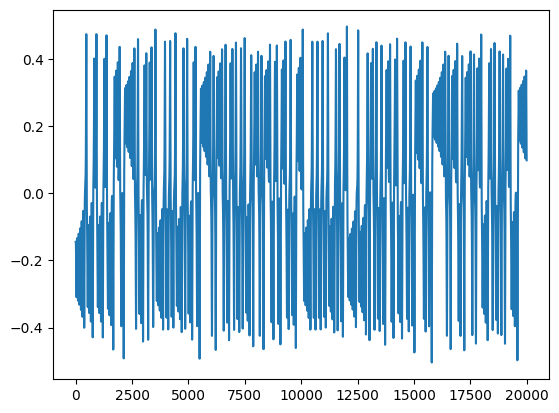

In [5]:
print(data_root_dir_cond)
print(data_root_dir_curr)

sup_cond = np.load(os.path.join(data_root_dir_cond, "supervisor.npy"))
sup_curr = np.load(os.path.join(data_root_dir_curr, "supervisor.npy"))

T = 20_000
dt = 1e-1
tau = 0.01
transient_time = 1000.0
nt = sup_cond.shape[0]
t_vec = np.arange(nt) * dt
x_init = np.array([1.0, 0.0, 0.5])
x = lorenz_forward(T, dt, tau, transient_time, x_init).T.copy()
minx = np.min(x, axis=0)
maxx = np.max(x, axis=0)
x_minmaxed = (x - minx) / (maxx - minx)
meanx = np.mean(x_minmaxed, axis=0)


plt.plot(t_vec, sup_cond[:, 0], label="x")
plt.show()

In [6]:
x.shape, sup_cond.shape

((200000, 3), (200000, 3))

(200000, 3)


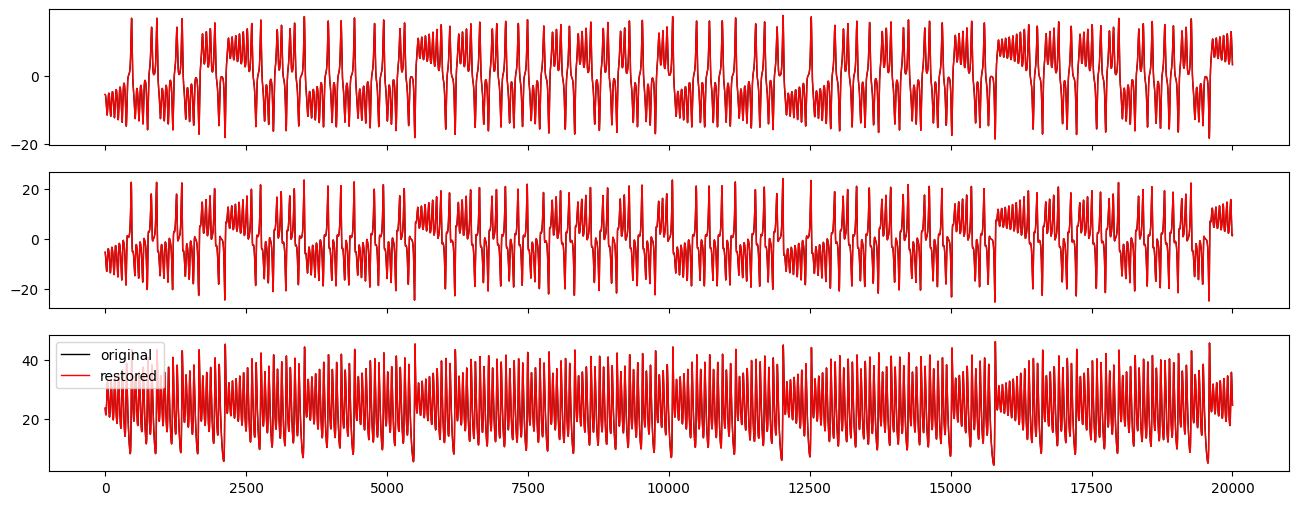

In [7]:
sup_cond_reverted = (sup_cond + meanx) * (maxx - minx) + minx
print(sup_cond_reverted.shape)
fig, ax = plt.subplots(3, 1, figsize=(16, 6), sharex=True)
for i in range(len(ax)):
    ax[i].plot(t_vec, x[:, i], "k-", lw=1, label="original")
    ax[i].plot(t_vec, sup_cond_reverted[:, i], "r-", lw=1, label="restored")

plt.legend()
plt.show()

In [8]:
def get_extended_error(
    xhat_rec: np.ndarray,
    sup: np.ndarray,
    idx_now: int,
    t_simulate: float,
    dt: float,
    tau: float = 0.01,
) -> np.ndarray[(3,), np.float64]:
    """Takes the current value of the reservoir output (`xhat_rec[idx_now]`)
    and simulates it for a duration `t_simulate` using the Lorenz dynamics.
    This acts as the target value. Then, the value of `xhat_rec[idx_now + round(t_simulate / dt)]`
    is taken as the reservoir output.

    Args:
        xhat_rec (np.ndarray):
            The reservoir output records
        sup (np.ndarray):
            The supervisor records
        idx_now (int):
            The current index to find the error for, should not be more than
            `xhat_rec.shape[0] - round(t_simulate / dt)`
        t_simulate (float):
            The duration to simulate to find the error
        dt (float):
            The time step value for the simulation
        tau (float):
            The integration timescale for the Lorenz simulation

    Returns:
        error (np.ndarray):
            The error vector defined as `output - target`
    """
    current_sup = (xhat_rec[idx_now].copy() + meanx) * (
        maxx - minx
    ) + minx  # revert the normalization
    sup_extend = lorenz_forward(
        t_simulate, dt, tau, transient_time=0.0, x_init=current_sup
    ).T
    sup_end = (sup_extend[-1] - minx) / (maxx - minx) - meanx  # normalize again
    nt_sim = sup_extend.shape[0]
    return xhat_rec[idx_now + nt_sim] - sup_end

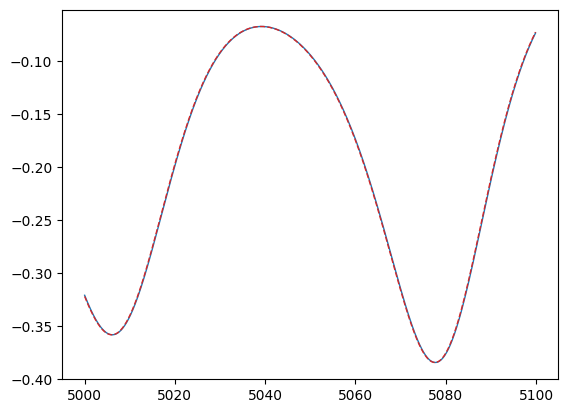

In [9]:
t_init = 5000  # ms
nt_init = int(t_init / dt)
duration = 100  # ms
nt_duration = int(duration / dt)

current_sup = (sup_cond[nt_init].copy() + meanx) * (maxx - minx) + minx

sup_cond_extend = lorenz_forward(
    duration, dt, tau, transient_time=0.0, x_init=current_sup
).T

sup_cond_extend = (sup_cond_extend - minx) / (maxx - minx) - meanx
# sup_cond_extend = (
#     LorenzAttractor(duration, dt, tau=0.01, init=sup_curr[nt_init].copy())
#     .generate(transient_time=0)
#     .T
# )
plt.plot(
    np.arange(t_init, t_init + duration, dt),
    sup_curr[nt_init : nt_init + nt_duration, 0],
    lw=1,
    c="tab:blue",
)
plt.plot(
    np.arange(t_init, t_init + duration, dt),
    sup_cond_extend[:, 0],
    lw=1,
    c="tab:red",
    ls="--",
)
plt.show()

In [10]:
len(os.listdir(data_root_dir_cond))

53

In [11]:
nt_split = int(nt / 2)
sup_cond_test = sup_cond[nt_split:]
sup_cond_train = sup_cond[:nt_split]

sup_curr_test = sup_curr[nt_split:]
sup_curr_train = sup_curr[:nt_split]

In [12]:
from scipy.signal import find_peaks


def get_return_map(data):
    peaks = data[find_peaks(data, distance=400)[0]]
    # peaks = peaks[peaks > 0]
    return_map = np.vstack([peaks[:-1], peaks[1:]])
    return return_map

In [13]:
def get_histogram(output_data: np.ndarray, sup_test: np.ndarray, n_bins: int = 100):
    """Get histogram of output data vs target data.

    Args:
        output_data (np.ndarray): The output data.
        sup_test (np.ndarray): The target data.
        n_bins (int): The number of bins for the histogram.

    Returns:
        list: A list of tuples containing the histograms for each axis. Each tuple contains (sup_hist, output_hist, bins).
    """
    hists = []
    for axis in range(sup_test.shape[1]):
        sup_hist, bins = np.histogram(sup_test[:, axis], bins=n_bins, density=True)
        output_hist, bins = np.histogram(output_data[:, axis], bins=bins, density=True)
        hists.append((sup_hist, output_hist, bins))
    return hists

In [14]:
def kl_div(hists: list[tuple]):
    """
    Calculate the KL divergence between two multi-dimensional histograms.
    """
    kl_div_values = []
    for i in range(len(hists)):
        sup_hist, output_hist, bins = hists[i]
        bin_size = bins[1] - bins[0]
        # Ensure both histograms are normalized
        sup_hist = sup_hist / np.sum(sup_hist) * bin_size
        output_hist = output_hist / np.sum(output_hist) * bin_size
        # Avoid division by zero and log of zero
        sup_hist = np.where(sup_hist == 0, 1e-10, sup_hist)
        output_hist = np.where(output_hist == 0, 1e-10, output_hist)
        # Calculate KL divergence
        kl_div_value = np.sum(sup_hist * np.log(sup_hist / output_hist))
        kl_div_values.append(kl_div_value)

    return kl_div_values


def rmse_marginal(hists: list[tuple]):
    rmse_values = []
    for i in range(len(hists)):
        sup_hist, output_hist, bins = hists[i]
        bin_size = bins[1] - bins[0]
        # Ensure both histograms are normalized
        sup_hist = sup_hist / np.sum(sup_hist) * bin_size
        output_hist = output_hist / np.sum(output_hist) * bin_size
        # Calculate RMSE
        rmse_value = np.sqrt(np.mean((sup_hist - output_hist) ** 2))
        rmse_values.append(rmse_value)

    return rmse_values

In [15]:
metrics_cond = []

for dirname in os.listdir(data_root_dir_cond):
    if dirname.endswith(".npy") or dirname.endswith(".json"):
        continue
    if dirname == "img":
        continue
    # extract parameters from the directory name
    match = re.match(r"w_in_amp_(\d+)p(\d+)_gbar_(\d+)p(\d+)", dirname)
    if not match:
        continue
    w_in_amp = eval(f"{match.group(1)}.{match.group(2)}")
    gbar = eval(f"{match.group(3)}.{match.group(4)}")
    print(f"Processing: {dirname} with w_in_amp={w_in_amp}, gbar={gbar}")
    # load the data
    data = {}
    data["Q"] = w_in_amp
    data["gbar"] = gbar
    data["dirname"] = dirname

    output_test = np.load(
        os.path.join(data_root_dir_cond, dirname, "output_data_test.npy")
    )
    data["output_test"] = output_test
    hists = get_histogram(output_test, sup_cond_test)
    data["kl_div"] = kl_div(hists)
    data["rmse"] = rmse_marginal(hists)
    data["return_map"] = get_return_map(output_test[:, -1])
    metrics_cond.append(data)

metrics_curr = []

for dirname in os.listdir(data_root_dir_curr):
    if dirname.endswith(".npy") or dirname.endswith(".json"):
        continue
    if dirname == "img":
        continue
    # extract parameters from the directory name
    match = re.match(r"w_in_amp_(\d+)p(\d+)_gbar_(\d+)p(\d+)", dirname)
    if not match:
        continue
    w_in_amp = eval(f"{match.group(1)}.{match.group(2)}")
    gbar = eval(f"{match.group(3)}.{match.group(4)}")
    print(f"Processing: {dirname} with w_in_amp={w_in_amp}, gbar={gbar}")
    # load the data
    data = {}
    data["Q"] = w_in_amp
    data["gbar"] = gbar
    data["dirname"] = dirname

    output_test = np.load(
        os.path.join(data_root_dir_curr, dirname, "output_data_test.npy")
    )
    data["output_test"] = output_test
    hists = get_histogram(output_test, sup_curr_test)
    data["kl_div"] = kl_div(hists)
    data["rmse"] = rmse_marginal(hists)
    data["return_map"] = get_return_map(output_test[:, -1])
    metrics_curr.append(data)

Processing: w_in_amp_100p0000_gbar_0p0000 with w_in_amp=100.0, gbar=0.0
Processing: w_in_amp_100p0000_gbar_5p0000 with w_in_amp=100.0, gbar=5.0
Processing: w_in_amp_100p0000_gbar_10p0000 with w_in_amp=100.0, gbar=10.0
Processing: w_in_amp_100p0000_gbar_15p0000 with w_in_amp=100.0, gbar=15.0
Processing: w_in_amp_100p0000_gbar_20p0000 with w_in_amp=100.0, gbar=20.0
Processing: w_in_amp_100p0000_gbar_25p0000 with w_in_amp=100.0, gbar=25.0
Processing: w_in_amp_100p0000_gbar_30p0000 with w_in_amp=100.0, gbar=30.0
Processing: w_in_amp_150p0000_gbar_0p0000 with w_in_amp=150.0, gbar=0.0
Processing: w_in_amp_150p0000_gbar_5p0000 with w_in_amp=150.0, gbar=5.0
Processing: w_in_amp_150p0000_gbar_10p0000 with w_in_amp=150.0, gbar=10.0
Processing: w_in_amp_150p0000_gbar_15p0000 with w_in_amp=150.0, gbar=15.0
Processing: w_in_amp_150p0000_gbar_20p0000 with w_in_amp=150.0, gbar=20.0
Processing: w_in_amp_150p0000_gbar_25p0000 with w_in_amp=150.0, gbar=25.0
Processing: w_in_amp_150p0000_gbar_30p0000 wit

In [16]:
len(metrics_cond), len(metrics_curr)

(49, 35)

In [17]:
cond_data = metrics_cond[9]

print(f"gbar = {cond_data['gbar']}, Q = {cond_data['Q']}")

cond_xhat_test = cond_data["output_test"]

t_delta = 10
nt_delta = round(t_delta / dt)

errors_cond = []
for i in tqdm(range(sup_cond_test.shape[0] - nt_delta)):
    errors_cond.append(
        get_extended_error(cond_xhat_test, sup_cond_test, i, t_delta, dt, tau)
    )

errors_cond = np.array(errors_cond)
errors_cond.shape

gbar = 10.0, Q = 150.0


100%|██████████| 99900/99900 [00:24<00:00, 4129.07it/s]


(99900, 3)

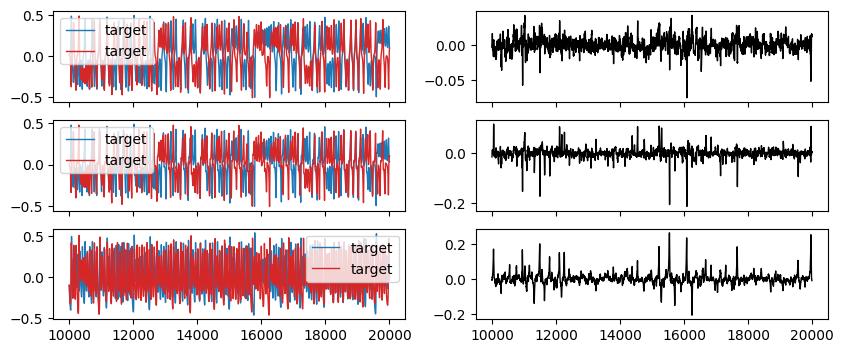

In [18]:
fig, ax = plt.subplots(3, 2, figsize=(10, 4), sharex=True)
for i in range(ax.shape[0]):
    ax[i, 0].plot(
        t_vec[nt_split:], sup_cond_test[:, i], lw=1, c="tab:blue", label="target"
    )
    ax[i, 0].plot(
        t_vec[nt_split:], cond_xhat_test[:, i], lw=1, c="tab:red", label="target"
    )
    ax[i, 1].plot(
        t_vec[nt_split:-nt_delta], errors_cond[:, i], lw=1, c="k", label="error"
    )
    ax[i, 0].legend()

plt.show(fig)

In [19]:
err_abs_mean = np.abs(errors_cond).mean(axis=0)
err_abs_mean

array([0.00720947, 0.01274122, 0.02075323])

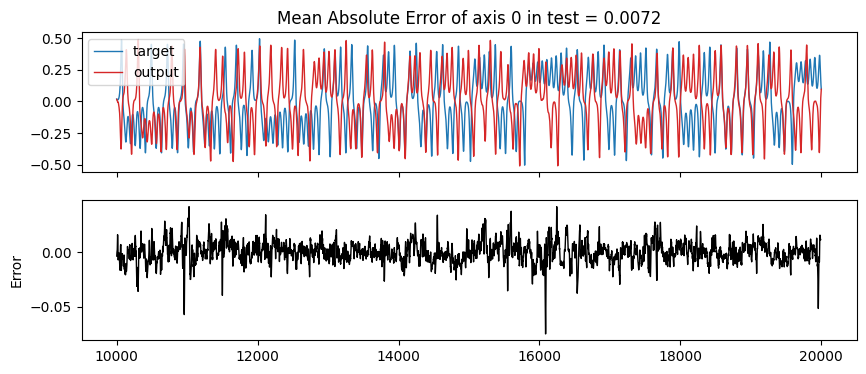

In [20]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax[0].set_title(f"Mean Absolute Error of axis 0 in test = {err_abs_mean[0]:.4f}")
ax[0].plot(t_vec[nt_split:], sup_cond_test[:, 0], lw=1, c="tab:blue", label="target")
ax[0].plot(t_vec[nt_split:], cond_xhat_test[:, 0], lw=1, c="tab:red", label="output")
ax[0].legend()
ax[1].plot(t_vec[nt_split:-nt_delta], errors_cond[:, 0], lw=1, c="k", label="error")
ax[1].set_ylabel("Error")
plt.show(fig)

In [21]:
curr_data = metrics_curr[6]

print(f"gbar = {curr_data['gbar']}, Q = {curr_data['Q']}")

curr_xhat_test = curr_data["output_test"]

t_delta = 10
nt_delta = round(t_delta / dt)

gbar = 10.0, Q = 300.0


In [22]:
errors_curr = []
for i in tqdm(range(sup_cond_test.shape[0] - nt_delta)):
    errors_curr.append(
        get_extended_error(curr_xhat_test, sup_curr_test, i, t_delta, dt, tau)
    )

errors_curr = np.array(errors_curr)
errors_curr.shape

100%|██████████| 99900/99900 [00:24<00:00, 4144.77it/s]


(99900, 3)

In [23]:
err_abs_mean_curr = np.abs(errors_curr).mean(axis=0)
err_abs_mean_curr

array([0.01002686, 0.01662156, 0.02214809])

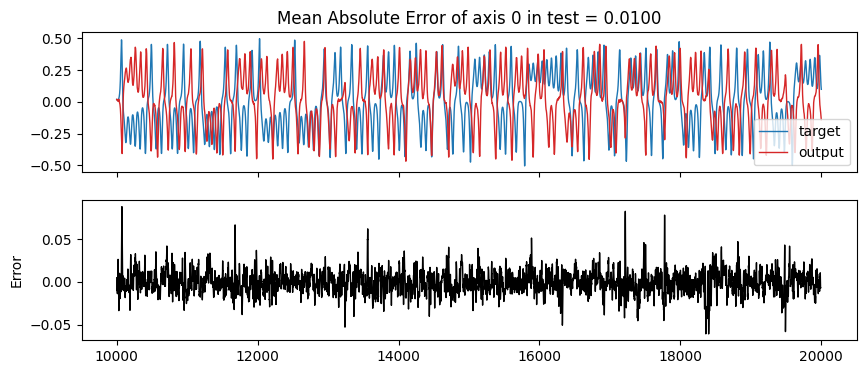

In [24]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax[0].set_title(f"Mean Absolute Error of axis 0 in test = {err_abs_mean_curr[0]:.4f}")
ax[0].plot(t_vec[nt_split:], sup_curr_test[:, 0], lw=1, c="tab:blue", label="target")
ax[0].plot(t_vec[nt_split:], curr_xhat_test[:, 0], lw=1, c="tab:red", label="output")
ax[0].legend()
ax[1].plot(t_vec[nt_split:-nt_delta], errors_curr[:, 0], lw=1, c="k", label="error")
ax[1].set_ylabel("Error")
plt.show(fig)

In [25]:
rmse_curr = np.sqrt(np.mean(errors_curr**2))
rmse_cond = np.sqrt(np.mean(errors_cond**2))
rmse_curr, rmse_cond

(np.float64(0.027749924144424513), np.float64(0.024179465416606035))

In [26]:
from typing import Any, List, Dict, Tuple


def find_param_range(
    total_stacked: List[List[Dict[str, Any]]],
) -> Dict[str, Tuple[float, float]]:
    Q_vals = []
    gbar_vals = []
    for row in total_stacked:
        for d in row:
            if "Q" in d and d["Q"] is not None:
                Q_vals.append(float(d["Q"]))
            if "gbar" in d and d["gbar"] is not None:
                gbar_vals.append(float(d["gbar"]))
    if not Q_vals or not gbar_vals:
        raise ValueError("No 'Q' or 'gbar' values found in total_stacked")
    return {"Q": (min(Q_vals), max(Q_vals)), "gbar": (min(gbar_vals), max(gbar_vals))}

In [27]:
total_sorted_cond = sorted(metrics_cond, key=lambda x: x["Q"])
total_sorted_curr = sorted(metrics_curr, key=lambda x: x["Q"])


def sort_stacked(total_sorted):
    total_stacked = []
    Qs = [data["Q"] for data in total_sorted]
    for value in np.unique(Qs):
        dummy = list()
        for data in total_sorted:
            if data["Q"] == value:
                dummy.append(data)
        total_stacked.append(sorted(dummy, key=lambda x: x["gbar"]))

    for lst in total_stacked:
        for data in lst:
            print(f"{data['Q']}, {data['gbar']}")
    return total_stacked


total_stacked_cond = sort_stacked(total_sorted_cond)
total_stacked_curr = sort_stacked(total_sorted_curr)

100.0, 0.0
100.0, 5.0
100.0, 10.0
100.0, 15.0
100.0, 20.0
100.0, 25.0
100.0, 30.0
150.0, 0.0
150.0, 5.0
150.0, 10.0
150.0, 15.0
150.0, 20.0
150.0, 25.0
150.0, 30.0
200.0, 0.0
200.0, 5.0
200.0, 10.0
200.0, 15.0
200.0, 20.0
200.0, 25.0
200.0, 30.0
250.0, 0.0
250.0, 5.0
250.0, 10.0
250.0, 15.0
250.0, 20.0
250.0, 25.0
250.0, 30.0
300.0, 0.0
300.0, 5.0
300.0, 10.0
300.0, 15.0
300.0, 20.0
300.0, 25.0
300.0, 30.0
350.0, 0.0
350.0, 5.0
350.0, 10.0
350.0, 15.0
350.0, 20.0
350.0, 25.0
350.0, 30.0
400.0, 0.0
400.0, 5.0
400.0, 10.0
400.0, 15.0
400.0, 20.0
400.0, 25.0
400.0, 30.0
300.0, 1.0
300.0, 2.5
300.0, 4.0
300.0, 5.5
300.0, 7.0
300.0, 8.5
300.0, 10.0
350.0, 1.0
350.0, 2.5
350.0, 4.0
350.0, 5.5
350.0, 7.0
350.0, 8.5
350.0, 10.0
400.0, 1.0
400.0, 2.5
400.0, 4.0
400.0, 5.5
400.0, 7.0
400.0, 8.5
400.0, 10.0
450.0, 1.0
450.0, 2.5
450.0, 4.0
450.0, 5.5
450.0, 7.0
450.0, 8.5
450.0, 10.0
500.0, 1.0
500.0, 2.5
500.0, 4.0
500.0, 5.5
500.0, 7.0
500.0, 8.5
500.0, 10.0


In [28]:
save_dir_cond = os.path.join(data_root_dir_cond, "img")
save_dir_curr = os.path.join(data_root_dir_curr, "img")

os.makedirs(save_dir_cond, exist_ok=True)
os.makedirs(save_dir_curr, exist_ok=True)

In [29]:
original_return_map_cond = get_return_map(sup_cond_test[:, -1])
original_return_map_curr = get_return_map(sup_curr_test[:, -1])

In [46]:
def calc_rmse_loss(
    total_stacked: List[List[Dict[str, Any]]],
    t_delta: float = 10.0,
    dt: float = 0.1,
    tau: float = 0.01,
) -> List[List[float]]:
    """Calculate RMSE loss using the `lorenz_forward` function to simulate the Lorenz dynamics for each output in `total_stacked`. The RMSE is computed between the simulated output and the actual output."""
    rmse_losses = []
    for i, row in enumerate(total_stacked):
        errors_row = []
        for j, data in enumerate(row):
            output_test = data["output_test"]
            errors = []
            for k in tqdm(range(sup_cond_test.shape[0] - nt_delta)):
                errors.append(
                    get_extended_error(output_test, sup_cond_test, k, t_delta, dt, tau)
                )
            errors = np.array(errors)
            rmse_loss = np.sqrt(np.mean(errors**2))
            data["rmse_loss"] = rmse_loss
            errors_row.append(rmse_loss)
        rmse_losses.append(errors_row)
    return rmse_losses

In [31]:
rmse_losses_cond = calc_rmse_loss(total_stacked_cond, t_delta, dt, tau)
rmse_losses_curr = calc_rmse_loss(total_stacked_curr, t_delta, dt, tau)

100%|██████████| 99900/99900 [00:24<00:00, 4097.23it/s]


In [49]:
rmse_losses_cond = np.array(
    [[data["rmse_loss"] for data in row] for row in total_stacked_cond]
)
rmse_losses_curr = np.array(
    [[data["rmse_loss"] for data in row] for row in total_stacked_curr]
)

rmse_losses_cond.shape

(7, 7)

In [61]:
np.save(os.path.join(save_dir_cond, "rmse_losses_cond.npy"), rmse_losses_cond)
np.save(os.path.join(save_dir_curr, "rmse_losses_curr.npy"), rmse_losses_curr)

In [33]:
rmse_losses_cond = np.log10(
    np.load(os.path.join(save_dir_cond, "rmse_losses_cond.npy"))
)
rmse_losses_curr = np.log10(
    np.load(os.path.join(save_dir_curr, "rmse_losses_curr.npy"))
)

In [34]:
import os, sys

sys.path.append(os.path.join(os.getcwd(), ".."))

from morris_lecar.plot_styles import set_thesis_style

set_thesis_style()

## Conductance-based Grid Search Data

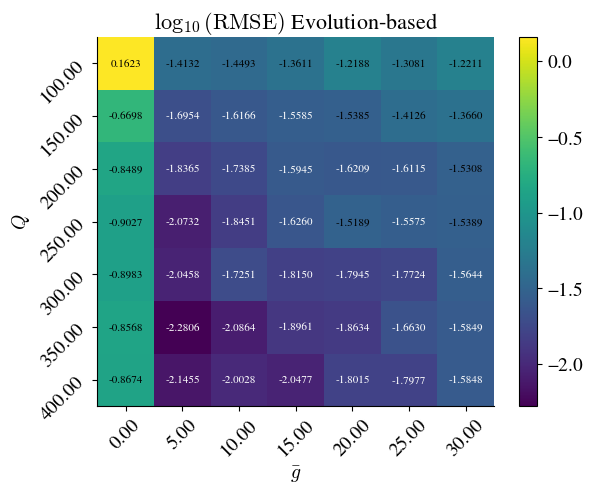

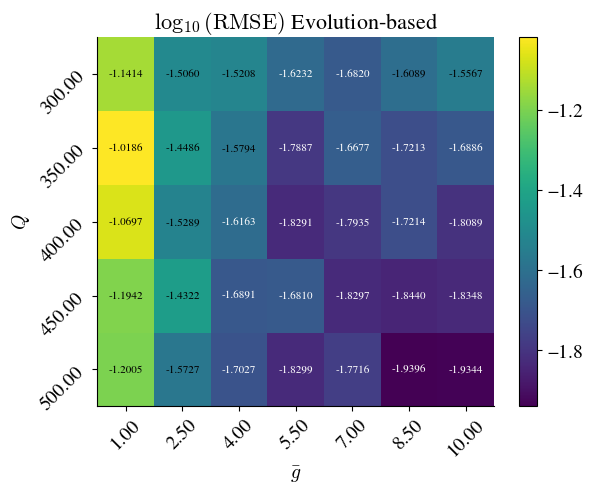

In [36]:
def plot_rmse_losses(losses: np.ndarray, total_stacked: List, save_dir: str) -> None:
    fig, ax = plt.subplots()
    cl = ax.pcolormesh(losses, cmap="viridis")
    mean_val = np.nanmean(losses)
    for i in range(losses.shape[0]):
        for j in range(losses.shape[1]):
            val = losses[i, j]
            txt = "nan" if np.isnan(val) else f"{val:.4f}"
            color = "white" if (not np.isnan(val) and val < mean_val) else "black"
            ax.text(
                j + 0.5, i + 0.5, txt, ha="center", va="center", color=color, fontsize=8
            )
    ax.set_xticks(
        ticks=np.arange(0.5, len(total_stacked[0]), 1.0),
        labels=[
            f"{total_stacked[0][i]['gbar']:.2f}" for i in range(len(total_stacked[0]))
        ],
        rotation=45,
    )
    ax.set_yticks(
        ticks=np.arange(0.5, len(total_stacked), 1.0),
        labels=[f"{total_stacked[i][0]['Q']:.2f}" for i in range(len(total_stacked))],
        rotation=45,
    )
    ax.set_title(r"$\log_{10}(\text{RMSE})$ Evolution-based", fontsize=16)
    ax.set_xlabel(r"$\bar{g}$")
    ax.set_ylabel(r"$Q$")
    ax.invert_yaxis()
    plt.colorbar(cl)

    plt.savefig(
        os.path.join(save_dir, "evolution_rmse_heatmap.pdf"), bbox_inches="tight"
    )
    plt.show(fig)
    plt.close(fig)


plot_rmse_losses(rmse_losses_cond, total_stacked_cond, save_dir_cond)
plot_rmse_losses(rmse_losses_curr, total_stacked_curr, save_dir_curr)

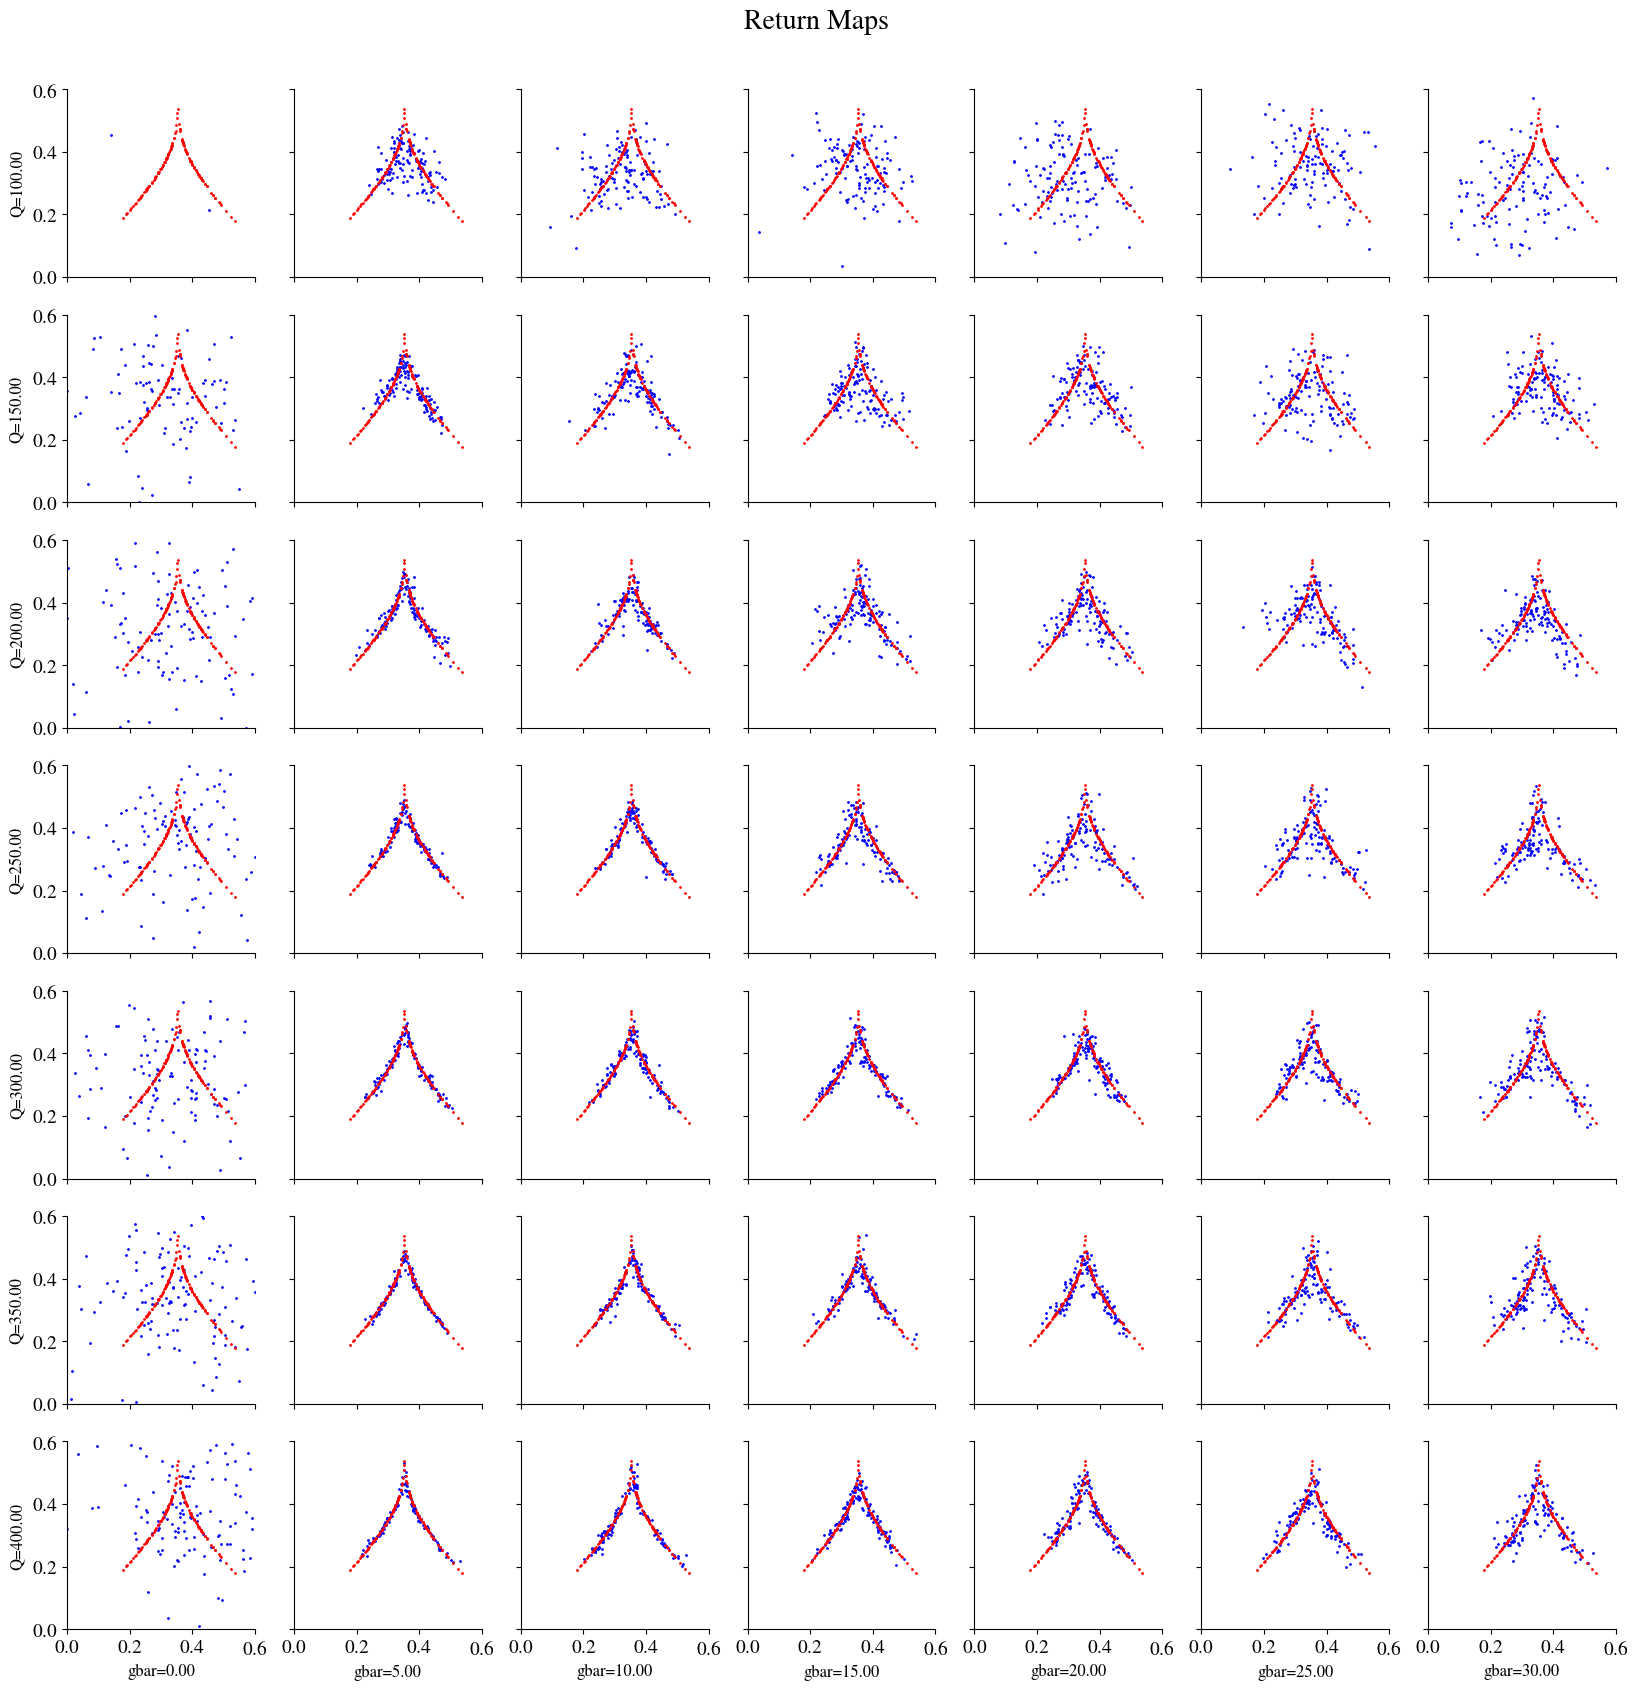

In [119]:
def plot_return_maps(total_stacked: List, original_return_map, save_dir: str):
    fig, ax = plt.subplots(
        len(total_stacked),
        len(total_stacked[0]),
        figsize=(20, 20),
        sharex=True,
        sharey=True,
    )

    for i in range(len(total_stacked)):
        ax[i, 0].set_ylabel(f"Q={total_stacked[i][0]['Q']:.2f}", fontsize=12)
        for j in range(len(total_stacked[i])):
            data = total_stacked[i][j]
            ax[i, j].scatter(data["return_map"][0], data["return_map"][1], c="b", s=1)
            ax[i, j].scatter(original_return_map[0], original_return_map[1], c="r", s=1)
            ax[i, j].set_xlim(0, 0.6)
            ax[i, j].set_ylim(0, 0.6)
            ax[i, j].set_aspect("equal", adjustable="box")

    for i in range(len(total_stacked[0])):
        ax[-1, i].set_xlabel(f"gbar={total_stacked[0][i]['gbar']:.2f}", fontsize=12)
    plt.suptitle("Return Maps", fontsize=20, y=0.92)
    plt.savefig(os.path.join(save_dir, "return_maps.pdf"), bbox_inches="tight")
    plt.show(fig)


plot_return_maps(total_stacked_cond, original_return_map_cond, save_dir_cond)

In [113]:
kl_div_values = [
    [total_stacked_cond[i][j]["kl_div"] for j in range(len(total_stacked_cond[i]))]
    for i in range(len(total_stacked_cond))
]

losses_cond = np.array(kl_div_values).sum(axis=2)
losses_cond[0, 0] = np.nan

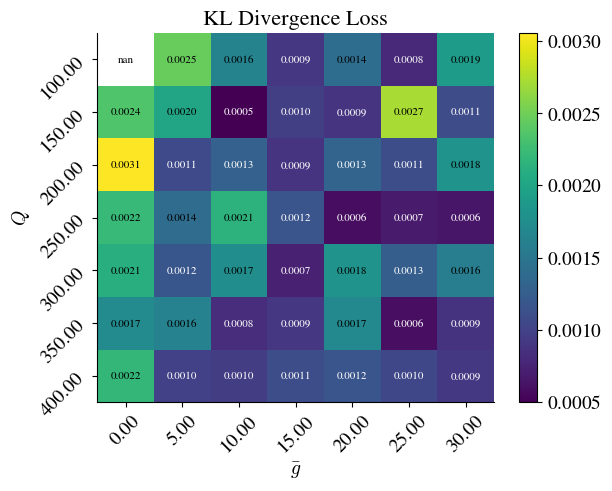

In [115]:
def plot_kldiv_heatmap(losses: np.ndarray, total_stacked: List, save_dir: str) -> None:
    fig, ax = plt.subplots()
    cl = ax.pcolormesh(losses, cmap="viridis")
    mean_val = np.nanmean(losses)
    for i in range(losses.shape[0]):
        for j in range(losses.shape[1]):
            val = losses[i, j]
            txt = "nan" if np.isnan(val) else f"{val:.4f}"
            color = "white" if (not np.isnan(val) and val < mean_val) else "black"
            ax.text(
                j + 0.5, i + 0.5, txt, ha="center", va="center", color=color, fontsize=8
            )
    ax.set_xticks(
        ticks=np.arange(0.5, len(total_stacked[0]), 1.0),
        labels=[
            f"{total_stacked[0][i]['gbar']:.2f}" for i in range(len(total_stacked[0]))
        ],
        rotation=45,
    )
    ax.set_yticks(
        ticks=np.arange(0.5, len(total_stacked), 1.0),
        labels=[f"{total_stacked[i][0]['Q']:.2f}" for i in range(len(total_stacked))],
        rotation=45,
    )
    ax.set_title("KL Divergence Loss", fontsize=16)
    ax.set_xlabel(r"$\bar{g}$")
    ax.set_ylabel(r"$Q$")
    ax.invert_yaxis()
    plt.colorbar(cl)

    plt.savefig(os.path.join(save_dir, "kl_div_heatmap.pdf"), bbox_inches="tight")
    plt.show(fig)
    plt.close(fig)


plot_kldiv_heatmap(losses_cond, total_stacked_cond, save_dir_cond)

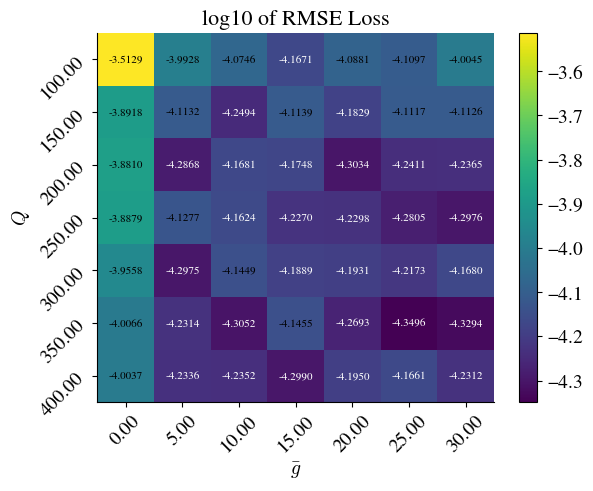

In [116]:
rmse_losses_cond = np.log10(
    np.array(
        [
            [
                np.sum(total_stacked_cond[i][j]["rmse"])
                for j in range(len(total_stacked_cond[i]))
            ]
            for i in range(len(total_stacked_cond))
        ]
    )
)


def plot_rmse_heatmap(rmse_losses, total_stacked: List, save_dir: str) -> None:
    fig, ax = plt.subplots()
    cl = ax.pcolormesh(rmse_losses, cmap="viridis")
    mean_val = np.nanmean(rmse_losses)
    for i in range(rmse_losses.shape[0]):
        for j in range(rmse_losses.shape[1]):
            val = rmse_losses[i, j]
            txt = "nan" if np.isnan(val) else f"{val:.4f}"
            color = "white" if (not np.isnan(val) and val < mean_val) else "black"
            ax.text(
                j + 0.5, i + 0.5, txt, ha="center", va="center", color=color, fontsize=8
            )
    ax.set_xticks(
        ticks=np.arange(0.5, len(total_stacked[0]), 1.0),
        labels=[
            f"{total_stacked[0][i]['gbar']:.2f}" for i in range(len(total_stacked[0]))
        ],
        rotation=45,
    )
    ax.set_yticks(
        ticks=np.arange(0.5, len(total_stacked), 1.0),
        labels=[f"{total_stacked[i][0]['Q']:.2f}" for i in range(len(total_stacked))],
        rotation=45,
    )
    ax.set_title("log10 of RMSE Loss", fontsize=16)
    ax.set_xlabel(r"$\bar{g}$")
    ax.set_ylabel(r"$Q$")
    ax.invert_yaxis()
    plt.colorbar(cl)
    plt.savefig(os.path.join(save_dir, "rmse_heatmap.pdf"), bbox_inches="tight")
    plt.show()


plot_rmse_heatmap(rmse_losses_cond, total_stacked_cond, save_dir_cond)

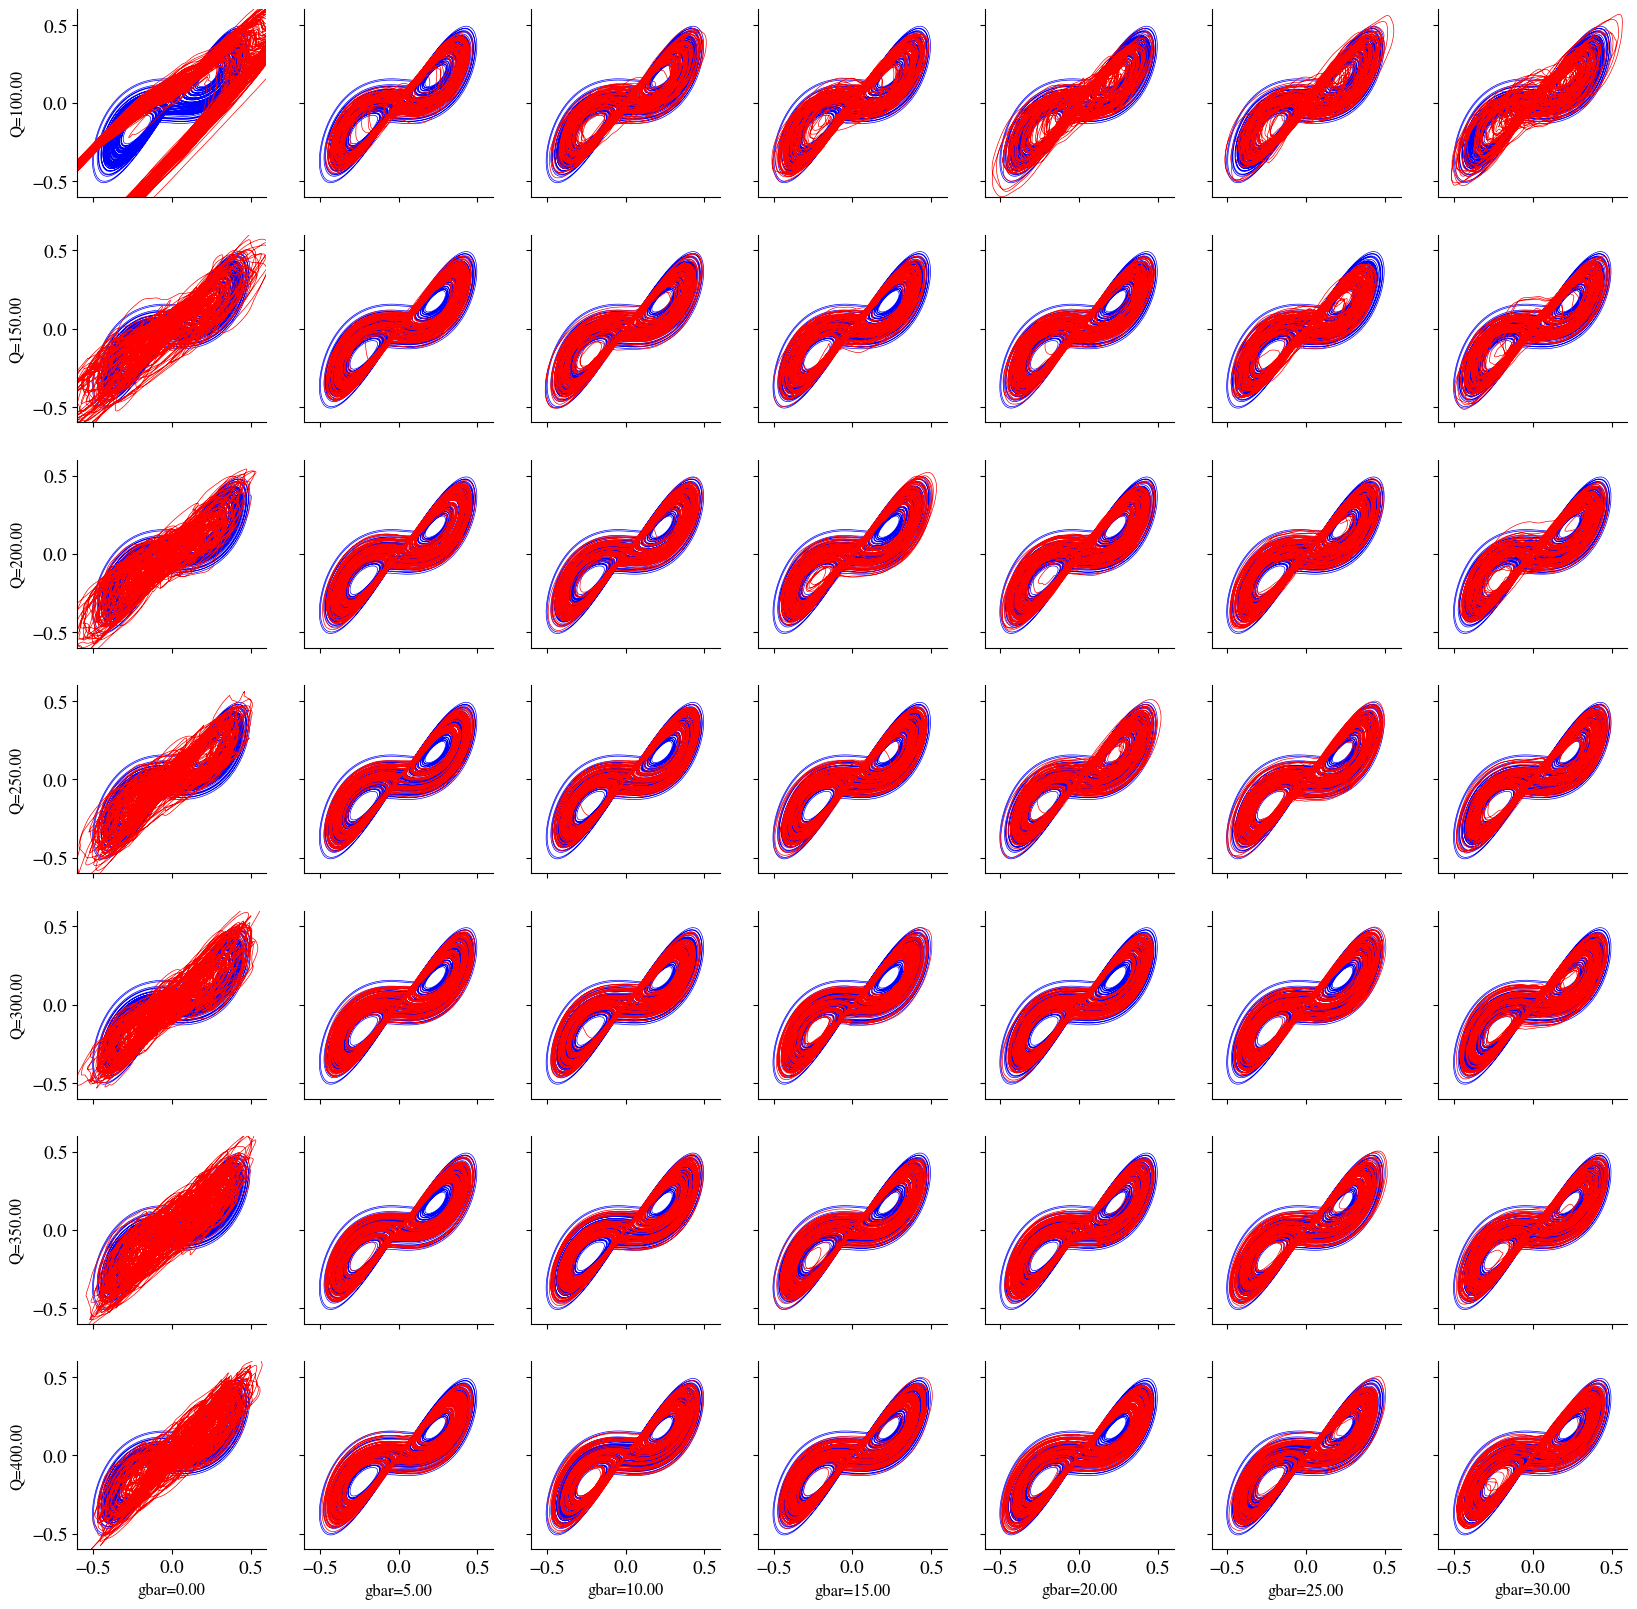

In [33]:
def plot_portraits(total_stacked: List, sup: np.ndarray, save_dir: str) -> None:
    fig, ax = plt.subplots(
        len(total_stacked),
        len(total_stacked[0]),
        figsize=(20, 20),
        sharex=True,
        sharey=True,
    )

    for i in range(len(total_stacked)):
        ax[i, 0].set_ylabel(f"Q={total_stacked[i][0]['Q']:.2f}", fontsize=12)
        for j in range(len(total_stacked[i])):
            data = total_stacked[i][j]
            ax[i, j].plot(sup[nt_split:, 0], sup[nt_split:, 1], lw=0.5, color="blue")
            ax[i, j].plot(
                data["output_test"][:, 0],
                data["output_test"][:, 1],
                lw=0.5,
                color="red",
            )
            # ax[i, j].set_title(f"Q={data['Q']:.1f}, gbar={data['gbar']:.1f}")

    for i in range(len(total_stacked[0])):
        ax[-1, i].set_xlabel(f"gbar={total_stacked[0][i]['gbar']:.2f}", fontsize=12)

    plt.xlim(-0.6, 0.6)
    plt.ylim(-0.6, 0.6)
    plt.savefig(os.path.join(save_dir, "x_y_phase_space.pdf"), bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_portraits(total_stacked_cond, sup_cond, save_dir_cond)

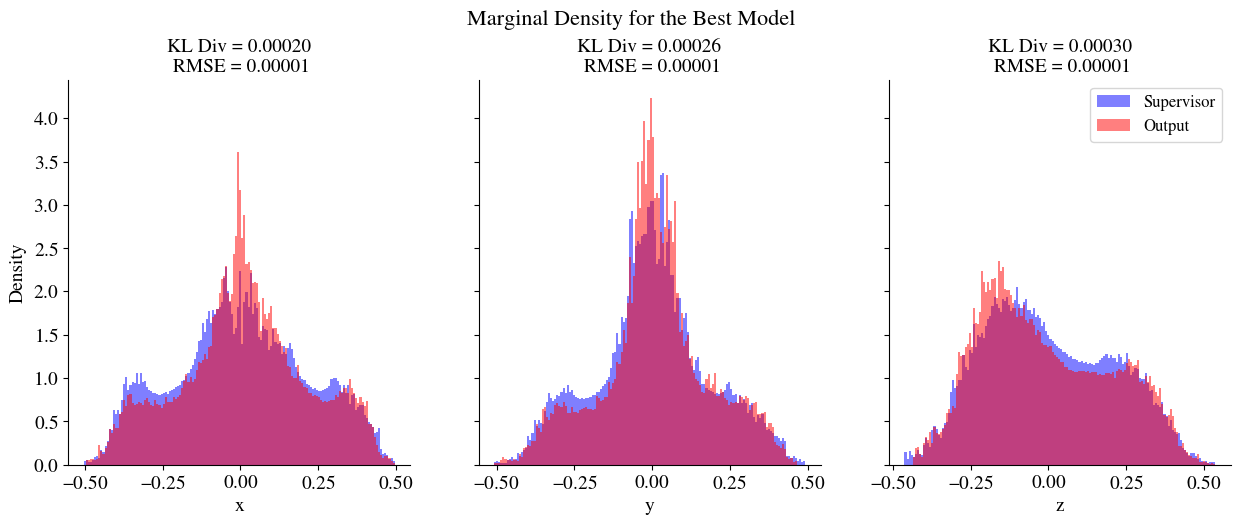

In [22]:
hists = get_histogram(total_stacked_cond[1][6]['output_test'], sup_cond_test, n_bins=150)

kl_div_value = kl_div(hists)
rmse = rmse_marginal(hists)

x_labels = ['x', 'y', 'z']

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for i in range(3):
    sup_hist, output_hist, bins = hists[i]
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax[i].bar(bin_centers, sup_hist, width=bin_centers[1] - bin_centers[0], alpha=0.5, color='blue', label='Supervisor')
    ax[i].bar(bin_centers, output_hist, width=bin_centers[1] - bin_centers[0], alpha=0.5, color='red', label='Output')
    ax[i].set_xlabel(x_labels[i])
    ax[i].set_title(f'KL Div = {kl_div_value[i]:.5f}\n RMSE = {rmse[i]:.5f}')
    
ax[-1].legend()
ax[0].set_ylabel('Density')
fig.suptitle("Marginal Density for the Best Model", fontsize=16, y=1.02)
plt.show(fig)

## Current-base Grid Search Data

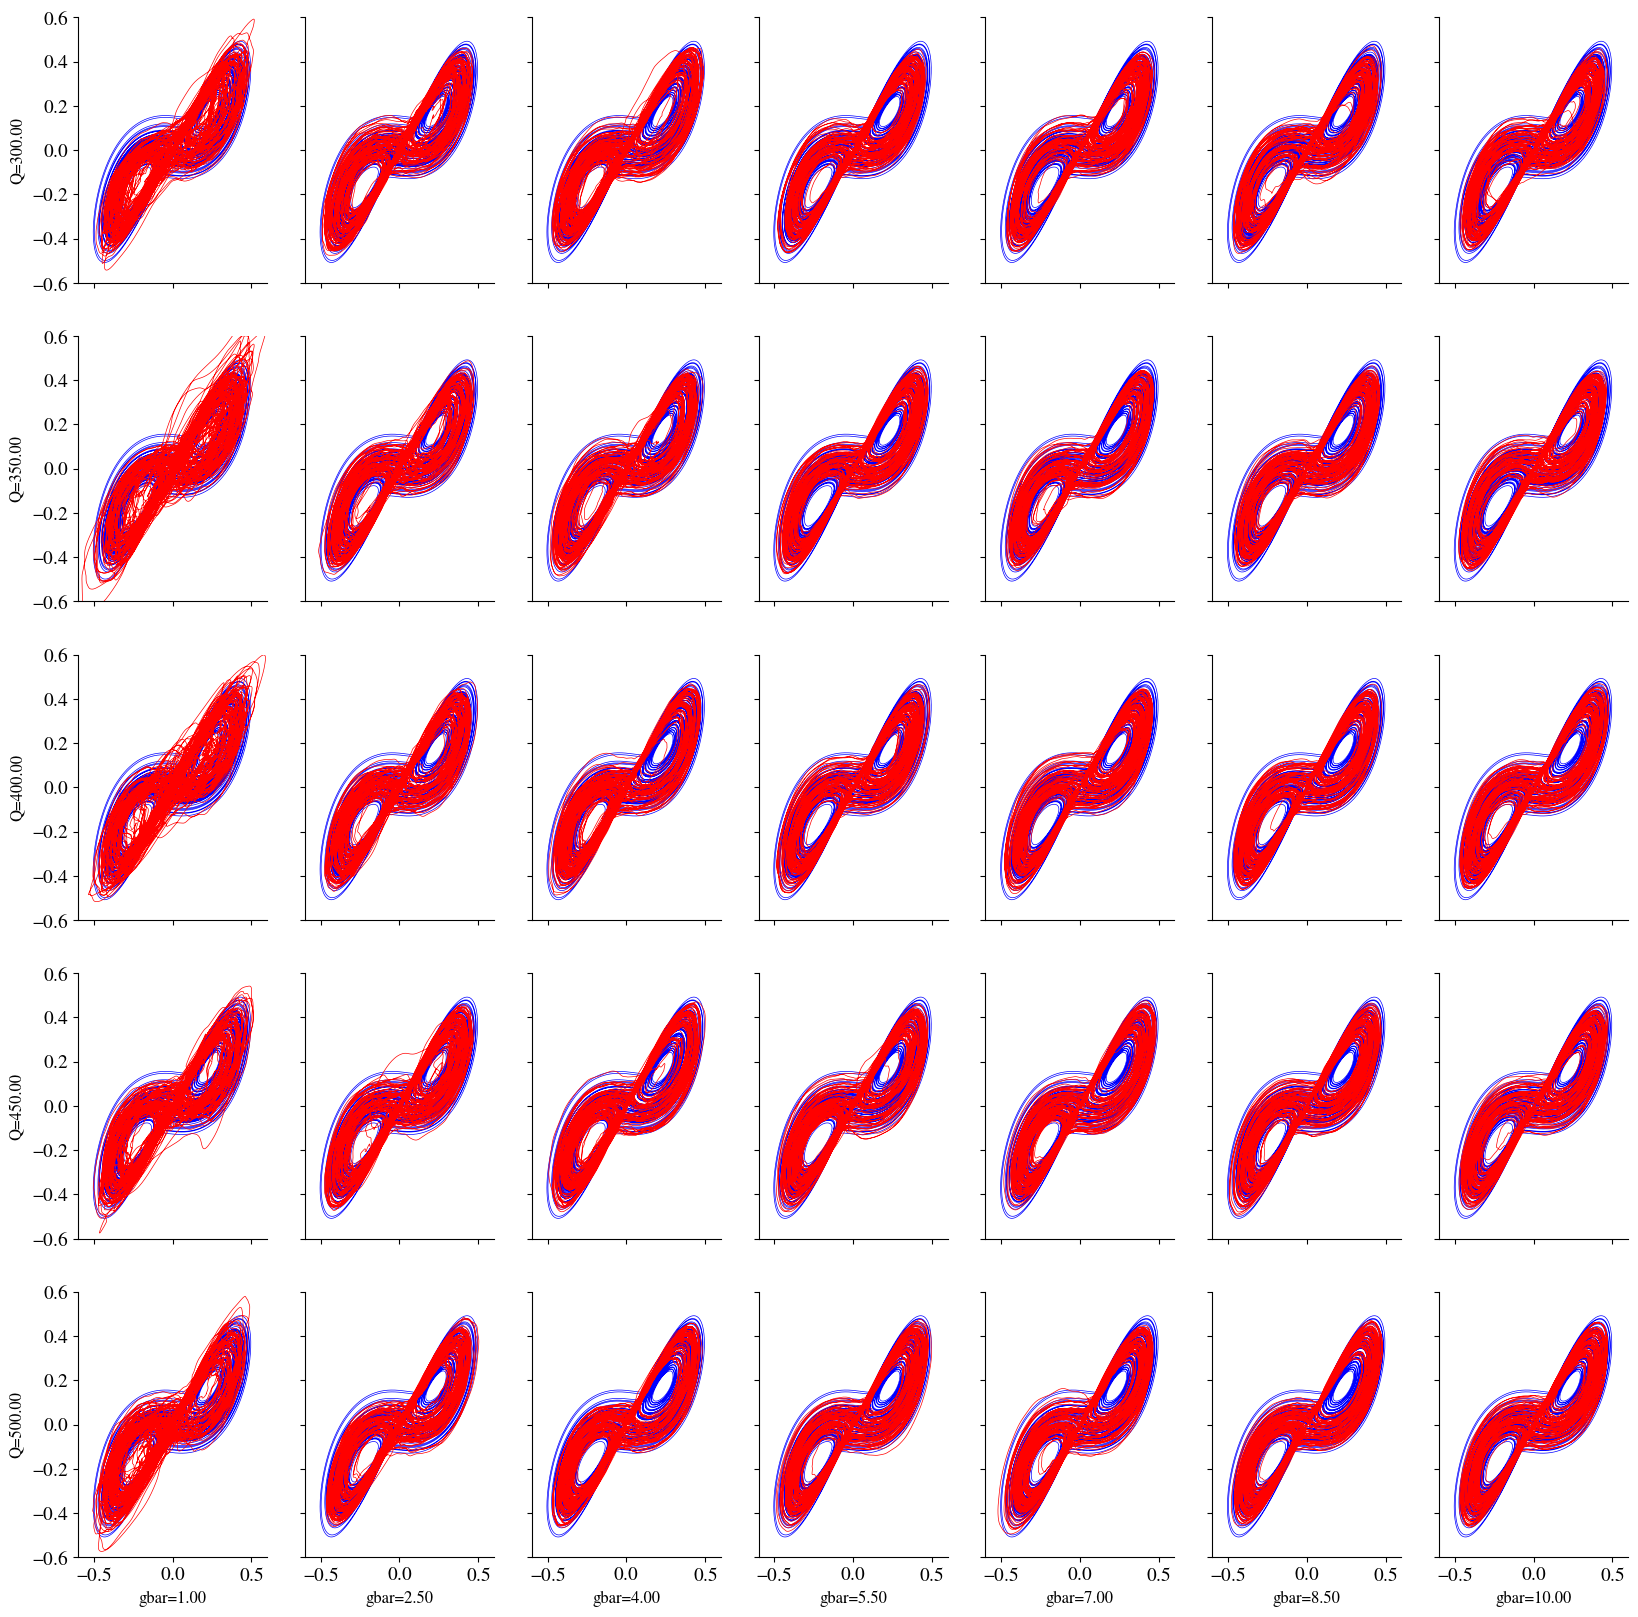

In [100]:
plot_portraits(total_stacked_curr, sup_curr, save_dir_curr)

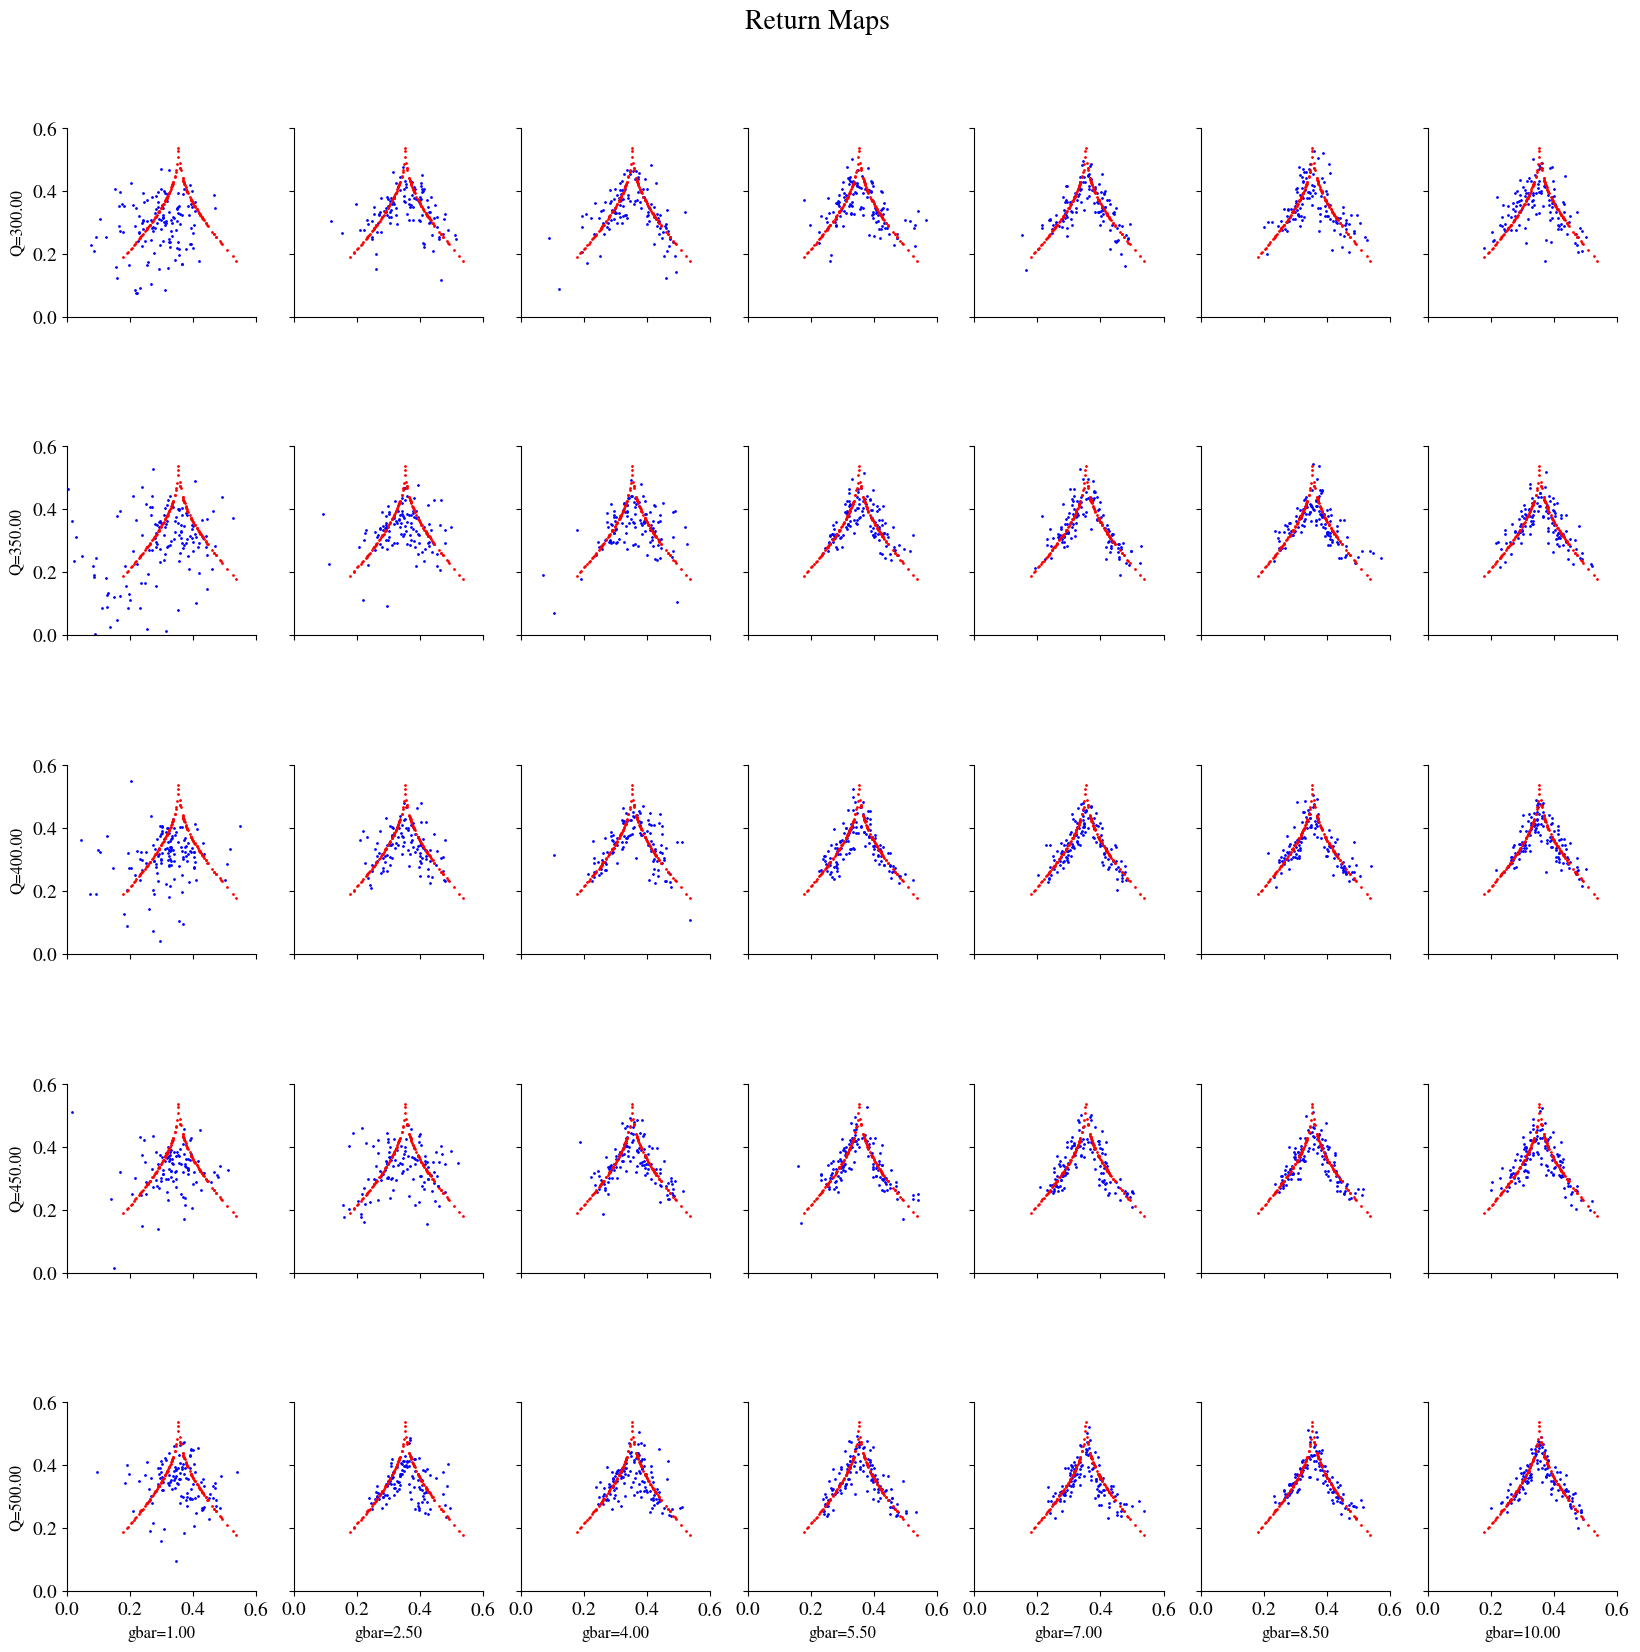

In [120]:
plot_return_maps(total_stacked_curr, original_return_map_curr, save_dir_curr)

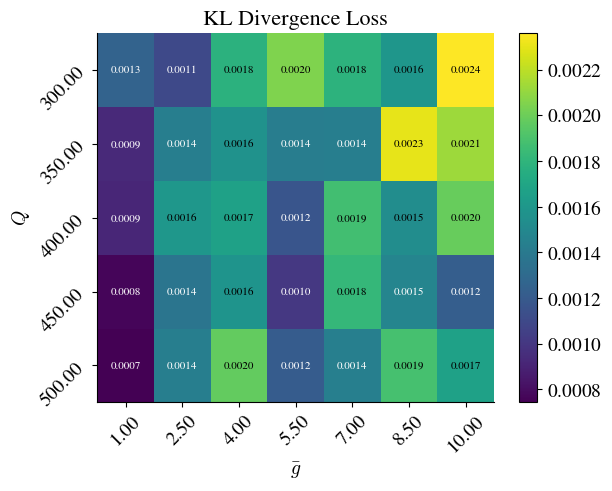

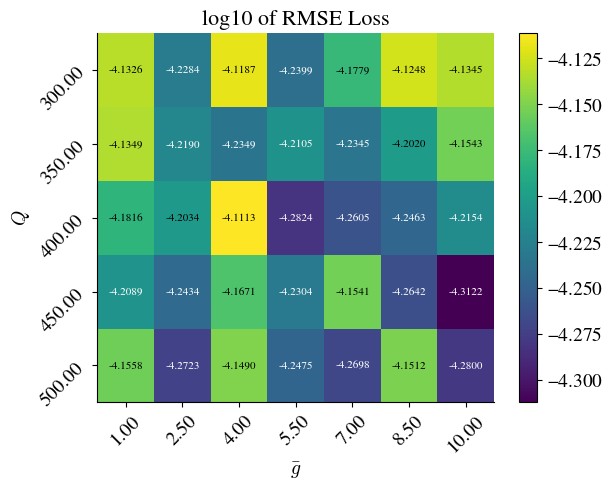

In [122]:
kl_div_values = [
    [total_stacked_curr[i][j]["kl_div"] for j in range(len(total_stacked_curr[i]))]
    for i in range(len(total_stacked_curr))
]

idxes = [1, 3, 4, 6]
# idxes = []
# for idx in idxes:
#     kl_div_values[idx].append([np.nan] * 3)

losses_curr = np.array(kl_div_values).sum(axis=2)
# losses_curr[0, 0] = np.nan
rmse_losses_curr = [
    [
        np.sum(total_stacked_curr[i][j]["rmse"])
        for j in range(len(total_stacked_curr[i]))
    ]
    for i in range(len(total_stacked_curr))
]
max_len = max(len(row) for row in rmse_losses_curr)
for row in rmse_losses_curr:
    while len(row) < max_len:
        row.append(np.nan)

rmse_losses_curr = np.log10(np.array(rmse_losses_curr))

plot_kldiv_heatmap(losses_curr, total_stacked_curr, save_dir_curr)
plot_rmse_heatmap(rmse_losses_curr, total_stacked_curr, save_dir_curr)